## EDA Notebook

This notebooks will show serval important charactristics of our dataset. I will show sample ekgs for men and women, the avg values of the noise indicators, signal quality by sex, human validated labels by fold, percentage of different devices used for men and women, signal amptutide by lead for men and women,

In [44]:
import os
PATH = '../data/'
for f in ['records100', 'ptbxl_database.csv', 'scp_statements.csv']:
    print(f, os.path.exists(PATH + f))

records100 True
ptbxl_database.csv True
scp_statements.csv True


In [45]:
import ast
import pandas as pd
df = pd.read_csv(PATH + 'ptbxl_database.csv', index_col = "ecg_id")

In [46]:
df["scp_codes"] = df['scp_codes'].apply(ast.literal_eval)

In [47]:
print(df.shape)
df.head()

(21799, 27)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


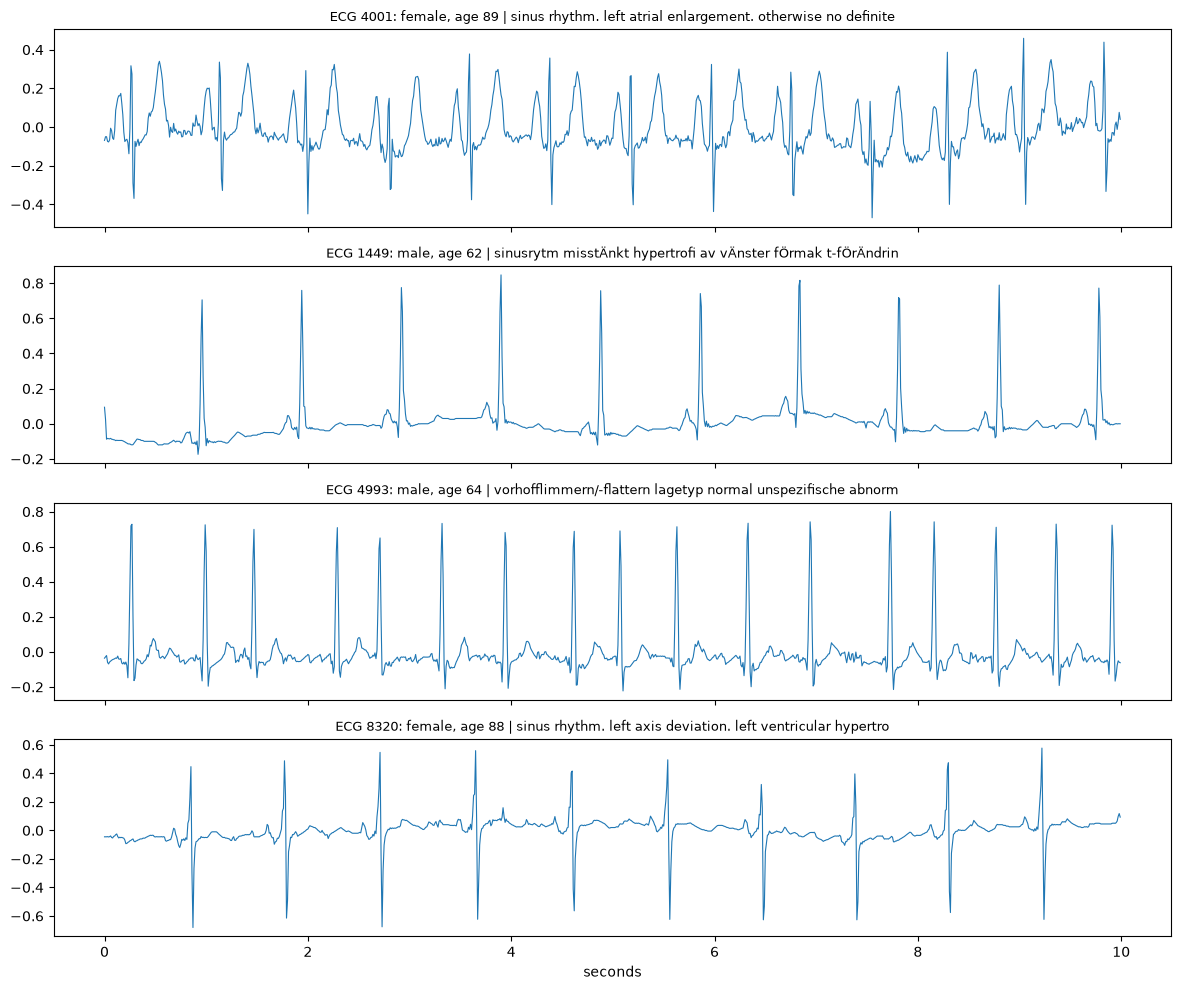

In [48]:
import wfdb, numpy as np, matplotlib.pyplot as plt

ex = df.sample(4, random_state=1)
t = np.arange(1000) / 100
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, (eid, row) in zip(axes, ex.iterrows()):
    sig, _ = wfdb.rdsamp(PATH + row['filename_lr'])
    ax.plot(t, sig[:, 1], lw=0.8)  # lead II
    sex = 'male' if row['sex'] == 0 else 'female'
    ax.set_title(f"ECG {eid}: {sex}, age {int(row['age'])} | {row['report'][:60]}", fontsize=9)
axes[-1].set_xlabel('seconds')
plt.tight_layout()
plt.show()

In [49]:
FLAGS = ['baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker']
print((df[FLAGS].notna().groupby(df['sex']).mean() * 100).round(1).T)
print('Human-validated:', round(df['validated_by_human'].mean() * 100, 1), '%')

sex                     0     1
baseline_drift        6.5   8.3
static_noise         15.7  14.1
burst_noise           3.3   2.2
electrodes_problems   0.1   0.2
extra_beats           9.9   7.9
pacemaker             1.4   1.3
Human-validated: 73.7 %


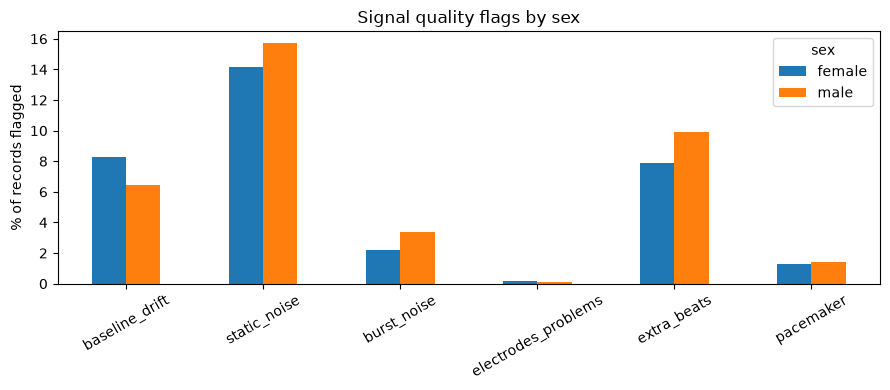

In [50]:
# 1. Noise flags by sex
FLAGS = ['baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker']
sexlab = df['sex'].map({0: 'male', 1: 'female'})
(df[FLAGS].notna().groupby(sexlab).mean() * 100).T.plot.bar(figsize=(9, 4), rot=30)
plt.ylabel('% of records flagged'); plt.title('Signal quality flags by sex')
plt.tight_layout()
plt.savefig('../figures/signal_quality_flags_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

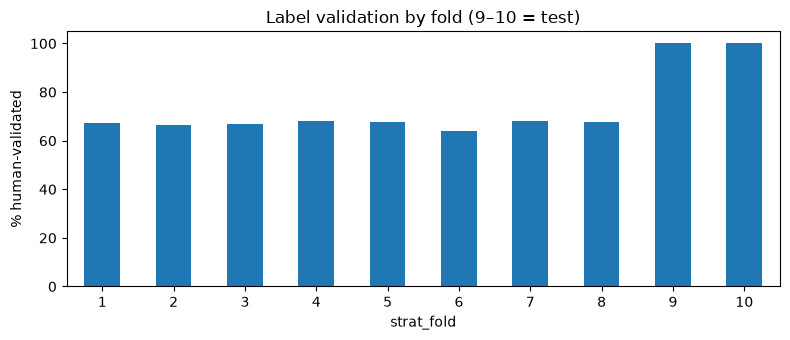

In [51]:
# 2. Human-validated labels by fold
(df.groupby('strat_fold')['validated_by_human'].mean() * 100).plot.bar(figsize=(8, 3.5), rot=0)
plt.ylabel('% human-validated'); plt.title('Label validation by fold (9–10 = test)')
plt.tight_layout()
plt.savefig('../figures/lab_validation_by_fold.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# 3. Recording device by sex
pd.crosstab(df['device'], sexlab, normalize='columns').mul(100).round(1)

sex,female,male
device,,
AT-6 6,11.8,9.1
AT-6 C,2.3,2.4
AT-6 C 5.0,0.5,0.2
AT-6 C 5.3,0.3,0.3
AT-6 C 5.5,20.1,16.3
AT-6 C 5.6,0.3,0.2
AT-6 C 5.8,4.4,3.2
AT-60 3,5.1,3.8
CS-12,21.4,16.0


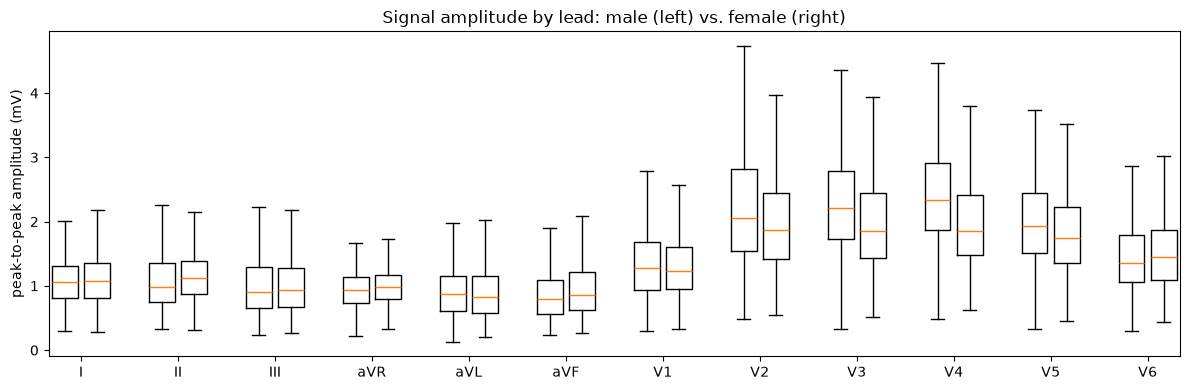

In [53]:
# 4. Signal amplitude by sex (sample of 1,000 records, takes ~1 min)
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
samp = df.sample(1000, random_state=0)
rows = []
for eid, row in samp.iterrows():
    sig, _ = wfdb.rdsamp(PATH + row['filename_lr'])
    amp = sig.max(axis=0) - sig.min(axis=0)  # peak-to-peak per lead
    rows.append(dict(zip(LEAD_NAMES, amp), sex=sexlab[eid]))
amp_df = pd.DataFrame(rows).melt(id_vars='sex', var_name='lead', value_name='mV')

fig, ax = plt.subplots(figsize=(12, 4))
for i, s in enumerate(['male', 'female']):
    d = amp_df[amp_df['sex'] == s]
    ax.boxplot([d[d['lead'] == l]['mV'] for l in LEAD_NAMES],
               positions=np.arange(12) * 3 + i, widths=0.8, showfliers=False)
ax.set_xticks(np.arange(12) * 3 + 0.5); ax.set_xticklabels(LEAD_NAMES)
ax.set_ylabel('peak-to-peak amplitude (mV)'); ax.set_title('Signal amplitude by lead: male (left) vs. female (right)')
plt.tight_layout()
plt.savefig('../figures/signal_amplitude_by_lead.png', dpi=150, bbox_inches='tight')
plt.show()

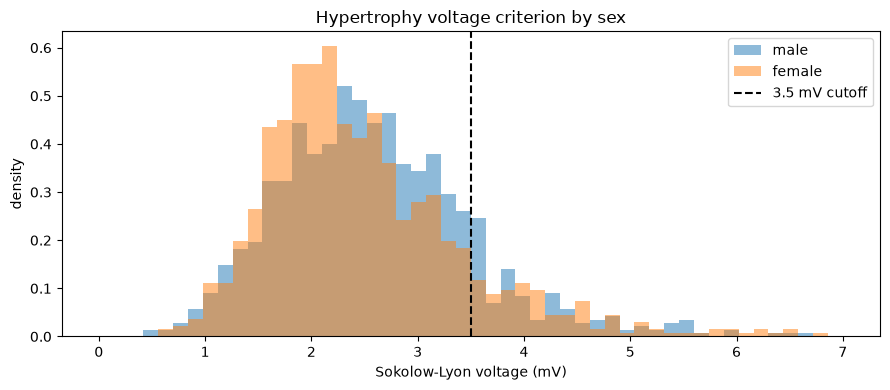

sex
female    12.9
male      14.5
Name: sokolow, dtype: float64 % over cutoff


In [54]:
samp = df.sample(2000, random_state=0)
rows = []
for eid, row in samp.iterrows():
    sig, _ = wfdb.rdsamp(PATH + row['filename_lr'])
    base = np.median(sig, axis=0)                   # flat line each lead sits on
    s_v1 = base[6] - sig[:, 6].min()                # S wave depth in V1
    r_v5v6 = max(sig[:, 10].max() - base[10],       # R wave height in V5
                 sig[:, 11].max() - base[11])       # ... or V6
    rows.append({'sex': sexlab[eid], 'sokolow': s_v1 + r_v5v6})
sl = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
for s in ['male', 'female']:
    ax.hist(sl[sl['sex'] == s]['sokolow'], bins=50, range=(0, 7), alpha=0.5, label=s, density=True)
ax.axvline(3.5, color='k', ls='--', label='3.5 mV cutoff')
ax.set_xlabel('Sokolow-Lyon voltage (mV)'); ax.set_ylabel('density')
ax.set_title('Hypertrophy voltage criterion by sex'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/hypertrophy_voltage_criterion_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

print((sl.groupby('sex')['sokolow'].apply(lambda x: (x > 3.5).mean()) * 100).round(1), '% over cutoff')